In [1]:
# sensitivity test for CLM5 parameters (21) accross the Continental US
# Import the required libraries
import csv
import functools
import math
import sys
import time
import random
import warnings
import subprocess
import argparse

# sys.path.append('C:/Users/hx293/Research_Data/BINN/')
# sys.path.append('/glade/u/home/haodixu/BINN')
# sys.path.append(r'/User/homes/ftao/Projects/BINNS/src_binns')
sys.path.append('/glade/work/haodixu/BINN')

# Set HDF5_DISABLE_VERSION_CHECK to suppress version mismatch error
import os
os.environ['HDF5_DISABLE_VERSION_CHECK'] = '2'
import psutil
import gc

from datetime import datetime, timedelta
import pandas as pd
from pandas import DataFrame as df
import numpy as np
from scipy.interpolate import pchip_interpolate
# parallel computing
# import concurrent.futures
# import torch.multiprocessing as mp
# # initialize the multiprocessing for pytorch
# mp.set_start_method('spawn', force=True)
print("Start binns_DDP")

import os
import torch



from scipy.io import loadmat
import netCDF4 as ncread 
import mat73

from matplotlib import pyplot as plt
from collections import OrderedDict

# Define input and output directories
input_dir = 'D:/Research/BINN/BINN_output/Sensitivity_Test_1000_Random_Seed_12355/'
data_dir_output = 'D:/Research/BINN/BINN_output/Sensitivity_Test_1000_Random_Seed_12355/'

Start binns_DDP


145
   parameters  sensitivity
1        cryo     0.001313
4      taucwd     0.001391
5       taul1     0.001417
6       taul2     0.001452
17      fs3s1     0.001560
7      tau4s1     0.001591
18     fcwdl2     0.002009
15      fs2s1     0.004974
10      fl1s1     0.005295
20       beta     0.012405
8      tau4s2     0.012824
12      fl3s2     0.015432
16      fs2s3     0.016445
0      diffus     0.017316
13      fs1s2     0.020199
2         q10     0.023214
11      fl2s1     0.023939
3    efolding     0.026445
14      fs1s3     0.084724
9      tau4s3     0.128320
19  w-scaling     0.485920


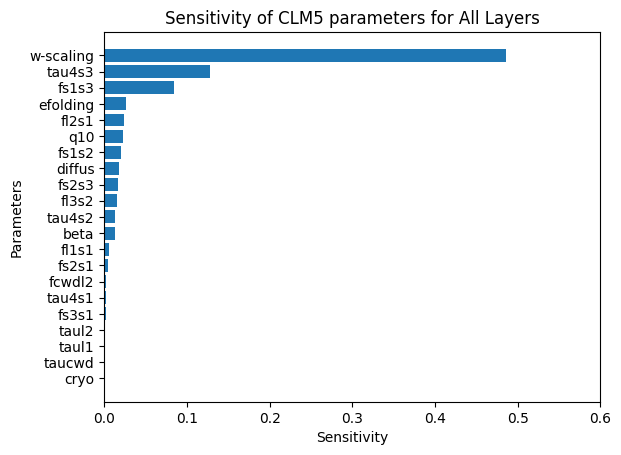

sensitivity_soc_all_sensitivity.png has been saved!


In [9]:
# Define the parameter names
para_names = ['diffus', 'cryo', 'q10', 'efolding', 'taucwd', 'taul1', 'taul2', 'tau4s1', 'tau4s2', 'tau4s3', 'fl1s1', 'fl2s1', 'fl3s2', 'fs1s2', 'fs1s3', 'fs2s1', 'fs2s3', 'fs3s1', 'fcwdl2', 'w-scaling', 'beta']
# Load parameter variance from csv and plot the bar chart
for i in range(1, 8):
	if i == 1:
		para_var_all = pd.read_csv(input_dir + 'sensitivity_soc_all_sensitivity_' + str(i) + '.csv')
		# Remove the first column
		para_var_all = para_var_all.drop(columns = ['Unnamed: 0'])
	else:
		para_var_all = pd.concat([para_var_all, pd.read_csv(input_dir + 'sensitivity_soc_all_sensitivity_' + str(i) + '.csv').drop(columns = ['Unnamed: 0'])], axis = 1)
# Rename the columns to 0-20
para_var_all.columns = range(21)
# Drop all the rows with NaN and Inf
para_var_all = para_var_all.replace([np.inf, -np.inf], np.nan).dropna()
# print the length of the dataframe
print(len(para_var_all))
# Calculate the mean value of each column
para_var_all_mean = para_var_all.mean()
# Create a dataframe to store the mean value and the parameter names
para_var_all_mean = pd.DataFrame(para_names, columns = ['parameters'])
para_var_all_mean['sensitivity'] = para_var_all.mean().values
# print(para_var_all_mean)
# print(para_var_all_mean)
# Sort the mean value in descending order
para_var_all_mean = para_var_all_mean.sort_values(by = 'sensitivity', ascending = True)
print(para_var_all_mean)
# Create a horizontal bar chart
fig, ax = plt.subplots()
ax.barh(para_var_all_mean['parameters'], para_var_all_mean['sensitivity'])
ax.set_xlabel('Sensitivity')
ax.set_ylabel('Parameters')
ax.set_title('Sensitivity of CLM5 parameters for All Layers')
# Set x-axis limit
ax.set_xlim(0, 0.6)
# Draw a red dash line at x = 0.2
# ax.axvline(x = 0.02, color = 'r', linestyle = '--')
plt.show()
# Save the figure
fig.savefig(data_dir_output + 'sensitivity_soc_all_sensitivity.png')
print('sensitivity_soc_all_sensitivity.png has been saved!')
# Print out the index of the parameters with sensitivity larger than 0.02
# print(para_var_all_mean[para_var_all_mean > 0.02].index)
# Check the sum of the sensitivity
# print(para_var_all_mean.sum())



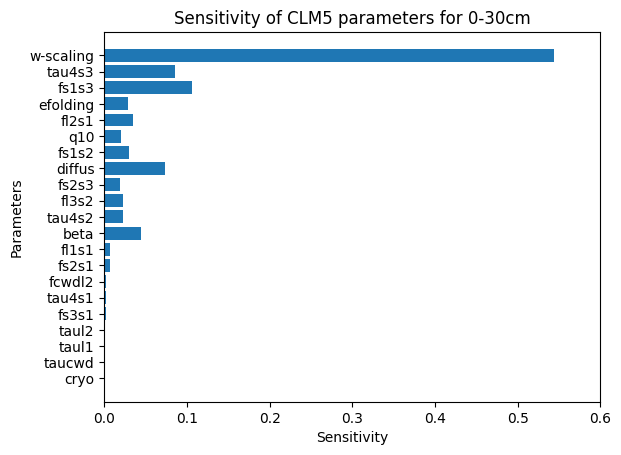

sensitivity_soc_0_30_sensitivity.png has been saved!
parameters          cryotaucwdtaul1taul2fs3s1tau4s1fcwdl2fs2s1fl1s...
sensitivity_all                                              0.888185
sensitivity_0_30                                             1.056503
dtype: object


In [6]:
# Load parameter variance from csv and plot the bar chart
for i in range(1, 8):
	if i == 1:
		para_var_0_30 = pd.read_csv(input_dir + 'sensitivity_soc_0_30_sensitivity_' + str(i) + '.csv')
		para_var_0_30 = para_var_0_30.drop(columns = ['Unnamed: 0'])
	else:
		para_var_0_30 = pd.concat([para_var_0_30, pd.read_csv(input_dir + 'sensitivity_soc_0_30_sensitivity_' + str(i) + '.csv').drop(columns = ['Unnamed: 0'])], axis = 1)
		# print("Length of para_var_0_30 in loop " + str(i) + " is " + str(len(para_var_0_30)))
# Rename the columns to 0-20
para_var_0_30.columns = range(21)
# Drop all the rows with NaN and Inf
para_var_0_30 = para_var_0_30.replace([np.inf, -np.inf], np.nan).dropna()
# Calculate the mean value of each column
para_var_0_30_mean = para_var_0_30.mean()
# Create a dataframe to store the mean value and the parameter names
para_var_0_30_mean = pd.DataFrame(para_names, columns = ['parameters'])
para_var_0_30_mean['sensitivity'] = para_var_0_30.mean().values
# Merge the two dataframes so that we can plot the second bar chart following the first one's order
para_var_0_30_mean = pd.merge(para_var_all_mean, para_var_0_30_mean, on = 'parameters', how = 'inner', suffixes = ('_all', '_0_30'))
# Create a horizontal bar chart
fig, ax = plt.subplots()
ax.barh(para_var_0_30_mean['parameters'], para_var_0_30_mean['sensitivity_0_30'])
ax.set_xlabel('Sensitivity')
ax.set_ylabel('Parameters')
ax.set_title('Sensitivity of CLM5 parameters for 0-30cm')
ax.set_xlim(0, 0.6)
# Draw a red dash line at x = 0.2
# ax.axvline(x = 0.2, color = 'r', linestyle = '--')
plt.show()
# Save the figure
fig.savefig(data_dir_output + 'sensitivity_soc_0_30_sensitivity.png')
print('sensitivity_soc_0_30_sensitivity.png has been saved!')

# Check the sum of the sensitivity
print(para_var_0_30_mean.sum())



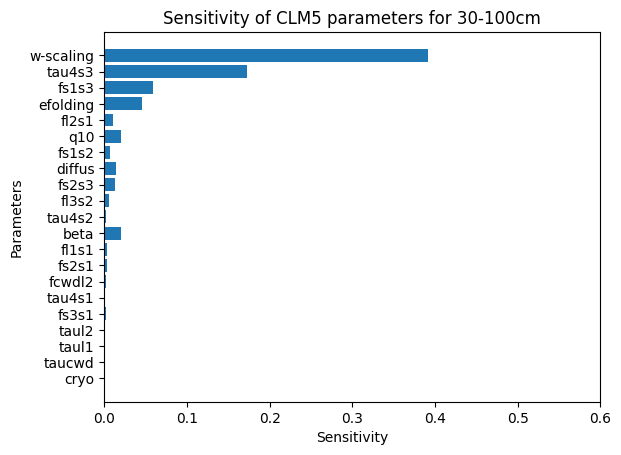

sensitivity_soc_30_100_sensitivity.png has been saved!
parameters            cryotaucwdtaul1taul2fs3s1tau4s1fcwdl2fs2s1fl1s...
sensitivity_all                                                0.888185
sensitivity_30_100                                              0.77794
dtype: object


In [7]:
# Load parameter variance from csv and plot the bar chart
for i in range(1, 8):
	if i == 1:
		para_var_30_100 = pd.read_csv(input_dir + 'sensitivity_soc_30_100_sensitivity_' + str(i) + '.csv')
		para_var_30_100 = para_var_30_100.drop(columns = ['Unnamed: 0'])
	else:
		para_var_30_100 = pd.concat([para_var_30_100, pd.read_csv(input_dir + 'sensitivity_soc_30_100_sensitivity_' + str(i) + '.csv').drop(columns = ['Unnamed: 0'])], axis = 1)
# Rename the columns to 0-20
para_var_30_100.columns = range(21)
# Drop all the rows with NaN and Inf
para_var_30_100 = para_var_30_100.replace([np.inf, -np.inf], np.nan).dropna()
# Calculate the mean value of each column
para_var_30_100_mean = para_var_30_100.mean()
# Create a dataframe to store the mean value and the parameter names
para_var_30_100_mean = pd.DataFrame(para_names, columns = ['parameters'])
para_var_30_100_mean['sensitivity'] = para_var_30_100.mean().values
# Merge the two dataframes so that we can plot the second bar chart following the first one's order
para_var_30_100_mean = pd.merge(para_var_all_mean, para_var_30_100_mean, on = 'parameters', how = 'inner', suffixes = ('_all', '_30_100'))
# Create a horizontal bar chart
fig, ax = plt.subplots()
ax.barh(para_var_30_100_mean['parameters'], para_var_30_100_mean['sensitivity_30_100'])
ax.set_xlabel('Sensitivity')
ax.set_ylabel('Parameters')
ax.set_title('Sensitivity of CLM5 parameters for 30-100cm')
ax.set_xlim(0, 0.6)
# Draw a red dash line at x = 0.2
# ax.axvline(x = 0.2, color = 'r', linestyle = '--')
plt.show()
# Save the figure
fig.savefig(data_dir_output + 'sensitivity_soc_30_100_sensitivity.png')
print('sensitivity_soc_30_100_sensitivity.png has been saved!')

# Check the sum of the sensitivity
print(para_var_30_100_mean.sum())

		

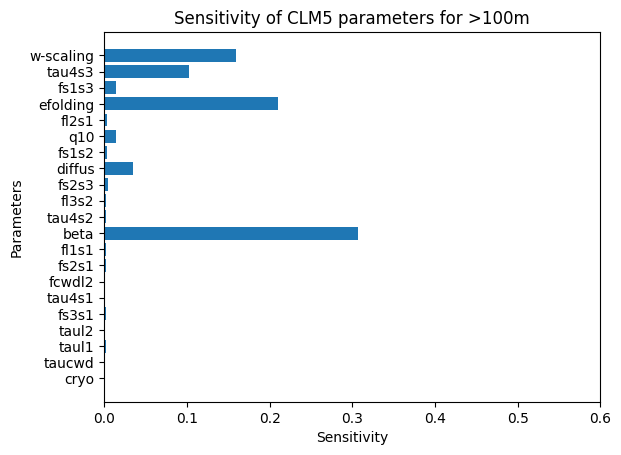

sensitivity_soc_100__sensitivity.png has been saved!
parameters          cryotaucwdtaul1taul2fs3s1tau4s1fcwdl2fs2s1fl1s...
sensitivity_all                                              0.888185
sensitivity_100_                                             0.870464
dtype: object


In [8]:
# Load parameter variance from csv and plot the bar chart
for i in range(1, 8):
	if i == 1:
		para_var_100_ = pd.read_csv(input_dir + 'sensitivity_soc_100__sensitivity_' + str(i) + '.csv')
		para_var_100_ = para_var_100_.drop(columns = ['Unnamed: 0'])
	else:
		para_var_100_ = pd.concat([para_var_100_, pd.read_csv(input_dir + 'sensitivity_soc_100__sensitivity_' + str(i) + '.csv').drop(columns = ['Unnamed: 0'])], axis = 1)
# Rename the columns to 0-20
para_var_100_.columns = range(21)
# Drop all the rows with NaN and Inf
para_var_100_ = para_var_100_.replace([np.inf, -np.inf], np.nan).dropna()
# Calculate the mean value of each column
para_var_100_mean = para_var_100_.mean()
# Create a dataframe to store the mean value and the parameter names
para_var_100_mean = pd.DataFrame(para_names, columns = ['parameters'])
para_var_100_mean['sensitivity'] = para_var_100_.mean().values
# Merge the two dataframes so that we can plot the second bar chart following the first one's order
para_var_100_mean = pd.merge(para_var_all_mean, para_var_100_mean, on = 'parameters', how = 'inner', suffixes = ('_all', '_100_'))
# Create a horizontal bar chart
fig, ax = plt.subplots()
ax.barh(para_var_100_mean['parameters'], para_var_100_mean['sensitivity_100_'])
ax.set_xlabel('Sensitivity')
ax.set_ylabel('Parameters')
ax.set_title('Sensitivity of CLM5 parameters for >100m')
ax.set_xlim(0, 0.6)
# Draw a red dash line at x = 0.2
# ax.axvline(x = 0.2, color = 'r', linestyle = '--')
plt.show()
# Save the figure
fig.savefig(data_dir_output + 'sensitivity_soc_100__sensitivity.png')
print('sensitivity_soc_100__sensitivity.png has been saved!')

# Check the sum of the sensitivity
print(para_var_100_mean.sum())